In [2]:
import lightkurve as lk
import numpy as np
import matplotlib.pyplot as plt

/opt/anaconda3/lib/python3.13/site-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


In [3]:
def download_m_dwarf_lc(tic_id):

    print(f"Searching MAST for 20-second cadence data (TIC {tic_id})...")
    result = lk.search_lightcurve(f"TIC {tic_id}", author="SPOC", exptime=20)
    
    if len(result) == 0:
        raise ValueError(f" No 20-second cadence SPOC data available {tic_id}")
    
    print(f"Found {len(result)} data sector")
    lc_collection = result.download_all()
    lc = lc_collection.stitch().normalize()
    lc = lc.remove_nans()
    
    print(f"Total data points: {len(lc)}")
    return lc
#Test execution
raw_lc = download_m_dwarf_lc(234295610)

Searching MAST for 20-second cadence data (TIC 234295610)...
Found 1 data sector
Total data points: 89865


In [4]:
def detrend_lc(lc, window_hours=6):
    window_len = int(window_hours * 180)
    # apply filter
    if window_len % 2 == 0:
        window_len += 1
    return lc.flatten(window_length=window_len, return_trend=True)

flat_lc, trend_lc = detrend_lc(raw_lc)

In [5]:
def find_flares(flat_lc, sigma_thresh=4.0, min_points=3):
    flux = flat_lc.flux.value
    med = np.median(flux)
    mad = np.median(np.abs(flux - med))
    sigma = 1.4826 * mad
    
    mask = flux > (med + sigma_thresh * sigma)
    idx = []
    i = 0
    while i < len(mask) - min_points:
        if all(mask[i : i + min_points]):
            for j in range(min_points):
                if (i + j) not in idx:
                    idx.append(i + j)
            i += min_points
        else:
            i += 1
    return np.array(idx), med, sigma

flare_idx, med, sigma = find_flares(flat_lc)
print(f"Flagged points: {len(flare_idx)}")

Flagged points: 69


In [6]:
def get_metrics(flat_lc, flare_idx, med, sigma):
    flux = flat_lc.flux.value
    time = flat_lc.time.value
    if len(flare_idx) == 0:
        return []
    
    groups = np.split(flare_idx, np.where(np.diff(flare_idx) > 15)[0] + 1)
    events = []
    
    for g in groups:
        if len(g) < 3: 
            continue
        p_idx = g[np.argmax(flux[g])]
        t_peak = time[p_idx]
        
        t_start_idx = g[0]
        while t_start_idx > 0 and flux[t_start_idx] > (med + 0.5 * sigma):
            t_start_idx -= 1
        t_start = time[t_start_idx]
        
        t_stop_idx = g[-1]
        while t_stop_idx < len(flux) - 1 and flux[t_stop_idx] > (med + 0.5 * sigma):
            t_stop_idx += 1
        t_stop = time[t_stop_idx]
        
        dt_rise = (t_peak - t_start) * 1440.0
        dt_total = (t_stop - t_start) * 1440.0
        
        if dt_total <= 0 or dt_rise <= 0 or dt_rise >= dt_total:
            continue
            
        events.append({
            "t_start": t_start,
            "t_peak": t_peak,
            "t_stop": t_stop,
            "rise_min": dt_rise,
            "tot_min": dt_total,
            "ratio": dt_rise / dt_total,
            "amp": flux[p_idx] - med
        })
    return events

flares = get_metrics(flat_lc, flare_idx, med, sigma)
print(f"Detected flares: {len(flares)}")

Detected flares: 4


Event Rise (m)    Total (m)   Ratio   
1     2.00        5.00        0.400   
2     6.33        25.67       0.247   
3     1.33        6.33        0.211   
4     1.67        4.67        0.357   


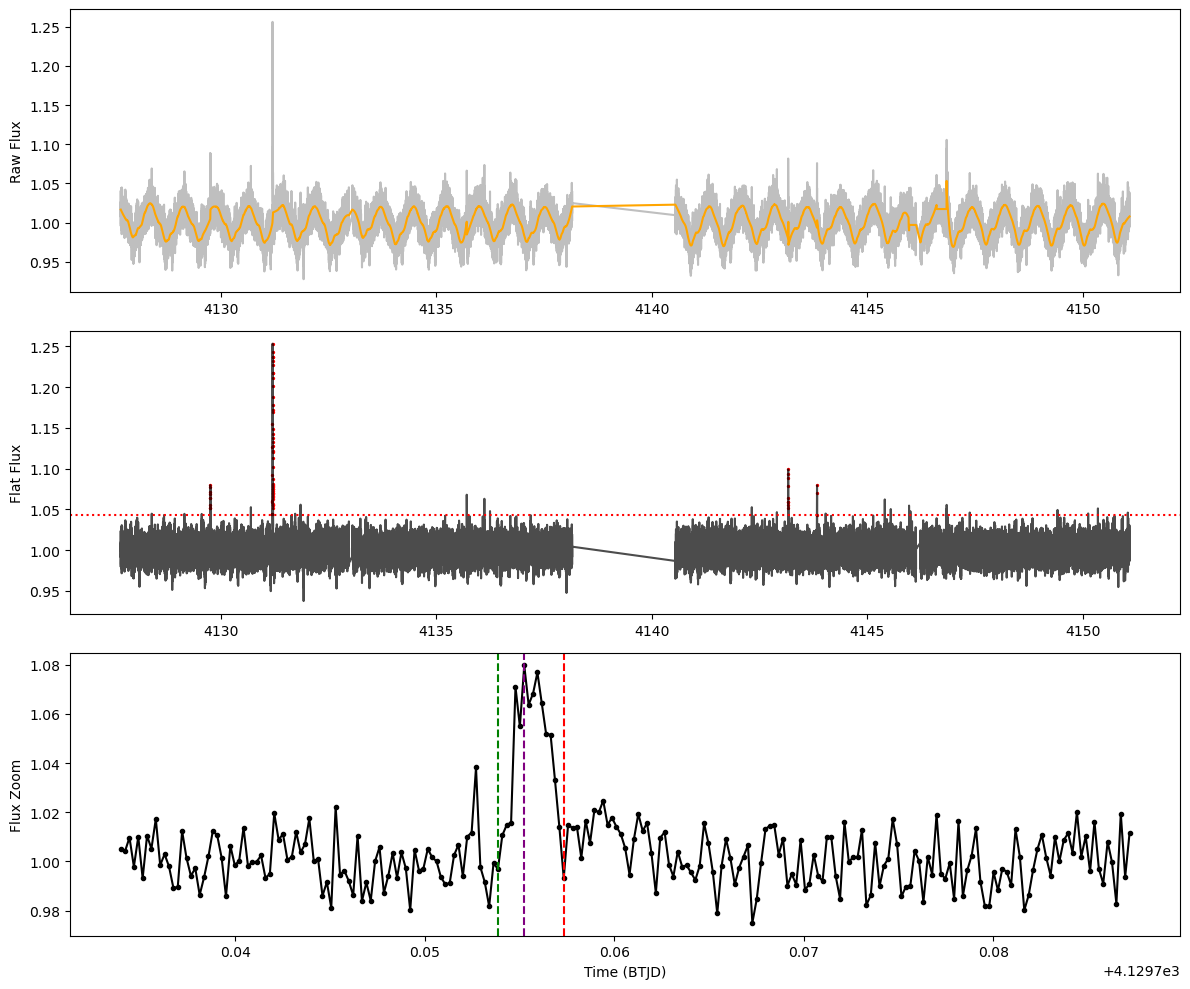

In [7]:
print(f"{'Event':<6}{'Rise (m)':<12}{'Total (m)':<12}{'Ratio':<8}")
for i, f in enumerate(flares):
    print(f"{i+1:<6}{f['rise_min']:<12.2f}{f['tot_min']:<12.2f}{f['ratio']:<8.3f}")

fig, ax = plt.subplots(3, 1, figsize=(12, 10))

ax[0].plot(raw_lc.time.value, raw_lc.flux.value, color='gray', alpha=0.5)
ax[0].plot(trend_lc.time.value, trend_lc.flux.value, color='orange')
ax[0].set_ylabel("Raw Flux")

ax[1].plot(flat_lc.time.value, flat_lc.flux.value, color='black', alpha=0.7)
if len(flare_idx) > 0:
    ax[1].scatter(flat_lc.time.value[flare_idx], flat_lc.flux.value[flare_idx], color='red', s=2)
ax[1].axhline(med + 4.0 * sigma, color='red', linestyle=':')
ax[1].set_ylabel("Flat Flux")

if len(flares) > 0:
    f = flares[0]
    zoom = (flat_lc.time.value > f['t_start'] - 0.02) & (flat_lc.time.value < f['t_stop'] + 0.03)
    ax[2].plot(flat_lc.time.value[zoom], flat_lc.flux.value[zoom], color='black', marker='o', ms=3)
    ax[2].axvline(f['t_start'], color='green', linestyle='--')
    ax[2].axvline(f['t_peak'], color='purple', linestyle='--')
    ax[2].axvline(f['t_stop'], color='red', linestyle='--')
    ax[2].set_xlabel("Time (BTJD)")
    ax[2].set_ylabel("Flux Zoom")

plt.tight_layout()
plt.show()

In [8]:
import os
import pandas as pd

df = pd.DataFrame(flares)
df["tic_id"] = 234295610
df["spectral_type"] = "M4V"

file_exists = os.path.isfile("extracted_flares.csv")
df.to_csv("extracted_flares.csv", mode="a", index=False, header=not file_exists)

print("Data added to 'extracted_flares.csv'.")

Data added to 'extracted_flares.csv'.
